# Module 17: Healthcare Informatics & Bio-Statistics
## Objective: Transforming medical data into clinical intelligence.

Healthcare data is high-stakes. In this module, we master the tools required 
to track regional outbreaks, manipulate specialized medical imaging formats, 
and optimize the efficiency of government medical centers like LRH.

### 1. Tracking the "Dengue Spike"
We use moving averages to filter out daily noise and identify the "Moment of 
Outbreak" (when the incidence rate exceeds the expected threshold).

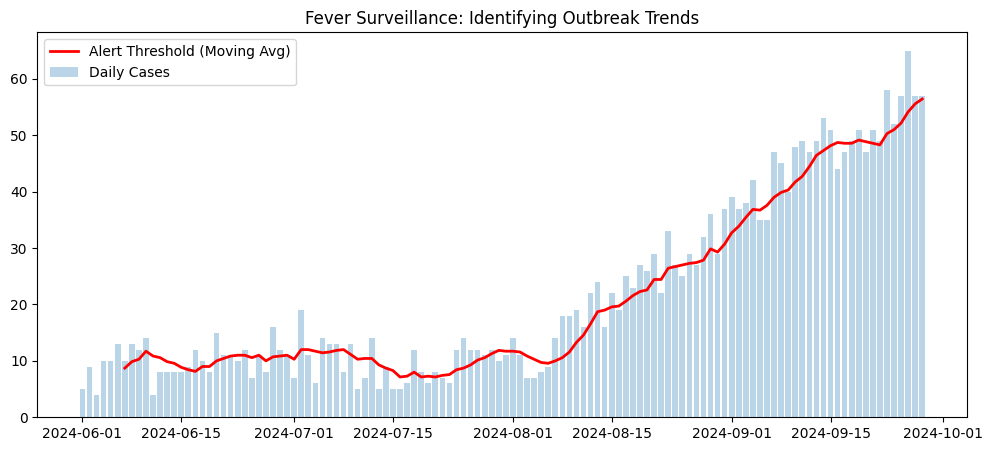

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Simulate 120 days of clinic admissions for "Fever" in Peshawar
dates = pd.date_range(start='2024-06-01', periods=120, freq='D')
base_cases = np.random.poisson(lam=10, size=120)

# Simulate an outbreak starting at Day 60
base_cases[60:] += np.linspace(0, 50, 60).astype(int)

surveillance_df = pd.DataFrame({'Daily_Admissions': base_cases}, index=dates)
surveillance_df['7D_Moving_Avg'] = surveillance_df['Daily_Admissions'].rolling(window=7).mean()

plt.figure(figsize=(12, 5))
plt.bar(surveillance_df.index, surveillance_df['Daily_Admissions'], alpha=0.3, label='Daily Cases')
plt.plot(surveillance_df['7D_Moving_Avg'], color='red', linewidth=2, label='Alert Threshold (Moving Avg)')
plt.title("Fever Surveillance: Identifying Outbreak Trends")
plt.legend()
plt.show()

### 2. Medical Imaging (DICOM) Basics
Unlike JPEG files, DICOM files contain a wealth of metadata. We use `pydicom` 
to read these headers and `matplotlib` to visualize the anatomical slices.

In [ ]:
# !pip install pydicom
import pydicom
import matplotlib.pyplot as plt

# Note: This logic assumes you have a sample .dcm file
def inspect_dicom(file_path):
    # ds = pydicom.dcmread(file_path)
    
    # Example of metadata extraction
    # print(f"Patient ID: {ds.PatientID}")
    # print(f"Modality: {ds.Modality}") # CT, MR, etc.
    
    # Visualizing the pixel data
    # plt.imshow(ds.pixel_array, cmap=plt.cm.bone)
    # plt.show()
    pass

print("PyDicom Pipeline: Ready for medical imaging segmentation tasks.")

PyDicom Pipeline: Ready for medical imaging segmentation tasks.


### 3. LRH Triage Optimization
Using the **Arrival Rate** and **Service Rate**, we can calculate the average 
time a patient spends in the system.

In [4]:
# Scenario: LRH Emergency Triage
arrival_rate = 20  # 20 patients per hour
service_rate = 25  # Triage can process 25 patients per hour

# Average time in the system (W) = 1 / (service_rate - arrival_rate)
wait_time_hours = 1 / (service_rate - arrival_rate)
wait_time_minutes = wait_time_hours * 60

print(f"Current Average Wait Time: {wait_time_minutes:.2f} minutes")

# Optimization: If we increase staff and service_rate becomes 30
optimized_wait = (1 / (30 - 20)) * 60
print(f"Optimized Wait Time (with more staff): {optimized_wait:.2f} minutes")

Current Average Wait Time: 12.00 minutes
Optimized Wait Time (with more staff): 6.00 minutes


### Student Exercise: The Medical Data Auditor
**Goal**: Analyze a simulated dataset of hospital discharge summaries.
1. Create a DataFrame with 100 entries: `Age`, `District`, `Diagnosis`, and `Wait_Time_Minutes`.
2. **Surveillance**: Identify which `District` has the highest number of "Flu" cases.
3. **Informatics**: Write a function that "Anonymizes" the `Age` by grouping 
   it into 10-year bins (e.g., 20-30).
4. **Optimization**: Calculate the average `Wait_Time_Minutes` for each `Diagnosis`.
5. **Wildcard**: Create a **Pie Chart** showing the distribution of patients 
   coming from Peshawar vs. Mardan vs. Charsadda.